# Aplicação Prática de Python na Ciência dos Dados - Parte 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df = pd.read_excel('dados2.xls')

In [8]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## Exercício 1: Criar listas para as características financeiras 
 Nesta etapa, organizamos os nomes das colunas em listas para facilitar a manipulação posterior.

In [26]:
bill_features = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
pay_features = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


Foram criadas listas separando as variáveis de valores de fatura e de pagamento, facilitando a análise e manipulação dos dados.

## Exercício 2: Síntese estatística dos valores das faturas
Este comando vai te mostrar a média, o valor máximo e o desvio padrão das faturas.

In [25]:
df[bill_features].describe()

,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6
count,30000.000000,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000
mean,50646.744233,48624.349167,4.649736e+04,42791.362167,39884.398167,38480.350933
std,73376.695080,70893.963498,6.910251e+04,64090.316188,60606.644833,59406.836932
min,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000
25%,3234.000000,2682.000000,2.403000e+03,2034.000000,1534.000000,1080.000000
50%,21644.500000,20597.000000,1.975250e+04,18759.500000,17835.500000,16643.000000
75%,66148.500000,62999.750000,5.952675e+04,53572.250000,49804.000000,48863.500000
max,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000


As estatísticas mostram grande variação entre valores mínimos e máximos, indicando alta dispersão nos dados. Também é possível observar valores muito elevados, sugerindo a presença de outliers. Isso faz sentido em dados financeiros, onde alguns clientes possuem gastos muito maiores que outros.

## Exercício 3: Visualização das faturas em histogramas
Criamos uma grade de 2x3 com 20 divisões (bins) para visualizar a distribuição dos valores das faturas.

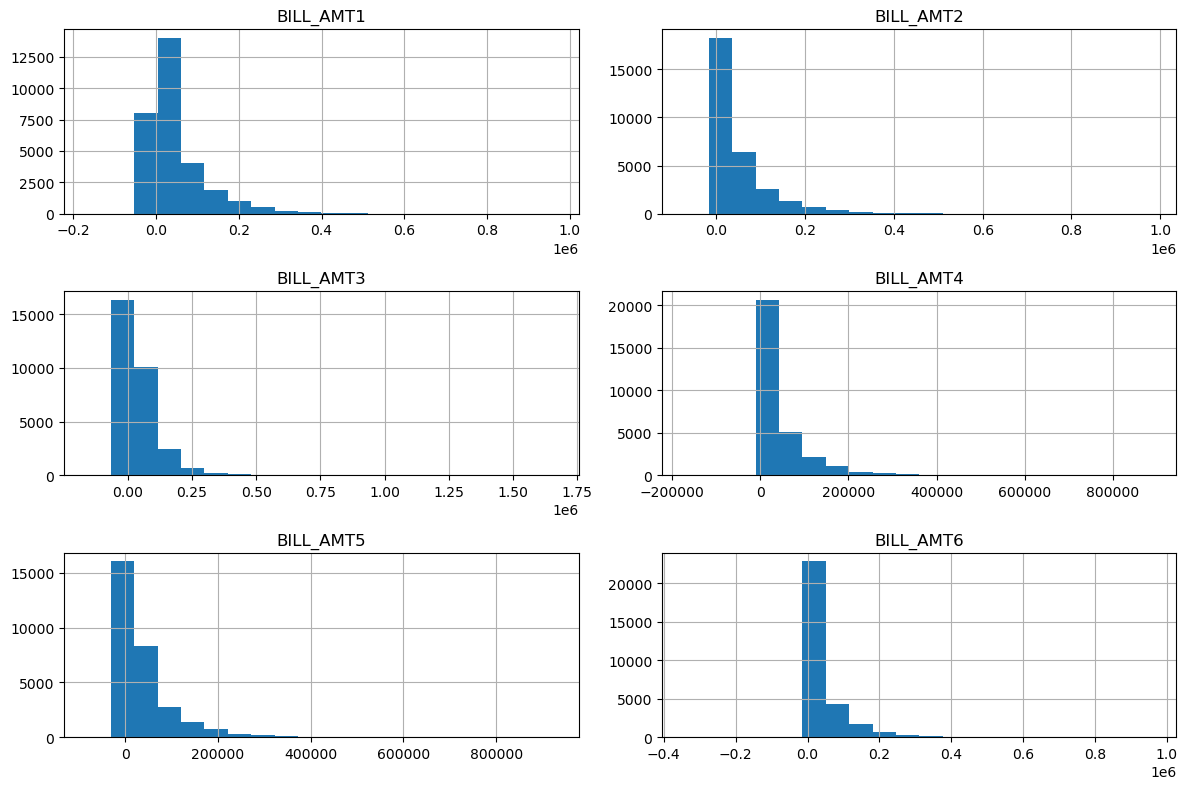

In [19]:
df[bill_features].hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

Os histogramas mostram uma distribuição assimétrica à direita, onde a maioria dos valores está concentrada em valores mais baixos, com poucos valores muito altos. Isso indica que a maior parte dos clientes possui faturas menores, enquanto poucos possuem valores elevados.

## Exercício 4: Síntese estatística dos valores de pagamento
Repetimos o processo estatístico, mas agora para as colunas de pagamentos realizados (PAY_AMT).

In [27]:
df[pay_features].describe()

,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
count,30000.000000,3.000000e+04,30000.000000,30000.000000,30000.000000,30000.000000
mean,5613.321500,5.855410e+03,5174.387967,4776.089733,4754.749200,5164.223267
std,16539.094312,2.299256e+04,17565.538305,15532.893047,15239.070708,17712.664703
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,836.000000,7.217500e+02,371.000000,223.000000,170.750000,9.000000
50%,2084.500000,2.000000e+03,1776.000000,1500.000000,1500.000000,1500.000000
75%,5000.000000,5.000000e+03,4500.000000,4000.000000,4000.000000,4000.000000
max,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


Os dados de pagamento apresentam muitos valores baixos e até zero, indicando que vários clientes não realizaram pagamentos em determinados períodos. A distribuição também apresenta alta variabilidade, o que é comum em dados financeiros.

## Exercício 5: Histogramas de pagamento com rotação nos eixos
Plotamos os histogramas de pagamento e usamos o argumento xrot para inclinar os nomes nos eixos e evitar que se sobreponham.

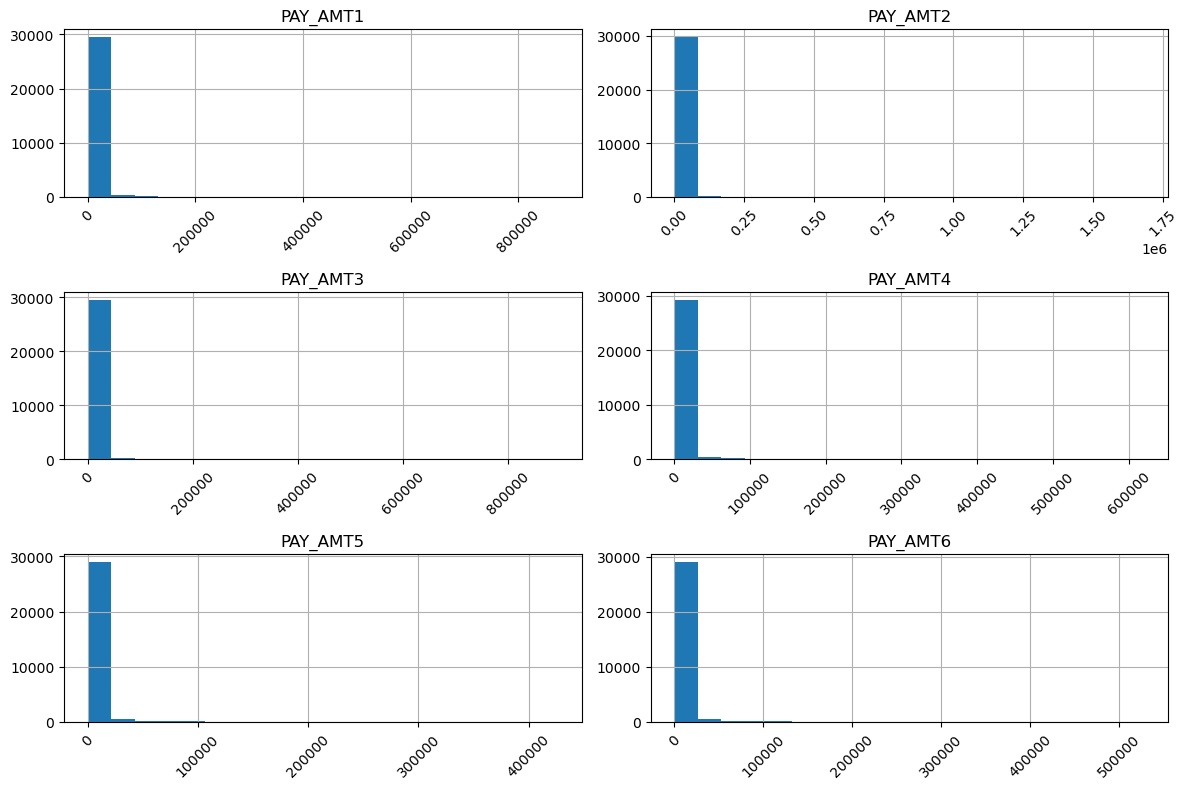

In [21]:
df[pay_features].hist(bins=20, figsize=(12,8), xrot=45)
plt.tight_layout()
plt.show()

Os histogramas mostram uma forte concentração de valores próximos de zero, reforçando que muitos pagamentos são baixos ou inexistentes. A rotação dos rótulos melhorou a visualização dos gráficos.

## Exercício 6: Identificação de pagamentos iguais a zero
Criamos uma "máscara booleana" para filtrar e contar quantos registros possuem valor de pagamento exatamente igual a 0.

In [22]:
zero_mask = df[pay_features] == 0
zero_count = zero_mask.sum()
zero_count

PAY_AMT1    5504
PAY_AMT2    5663
PAY_AMT3    6223
PAY_AMT4    6660
PAY_AMT5    6955
PAY_AMT6    7416
dtype: int64

Observa-se uma grande quantidade de valores iguais a zero nos dados de pagamento, o que confirma o padrão visto nos histogramas anteriores. Isso indica que muitos clientes não efetuaram pagamentos em alguns períodos.

## Exercício 7: Transformação Logarítmica (Log10)
Como os valores de pagamento variam muito, aplicamos o logaritmo na base 10 (usando np.log10 do NumPy) apenas nos pagamentos maiores que zero para ver melhor a distribuição.

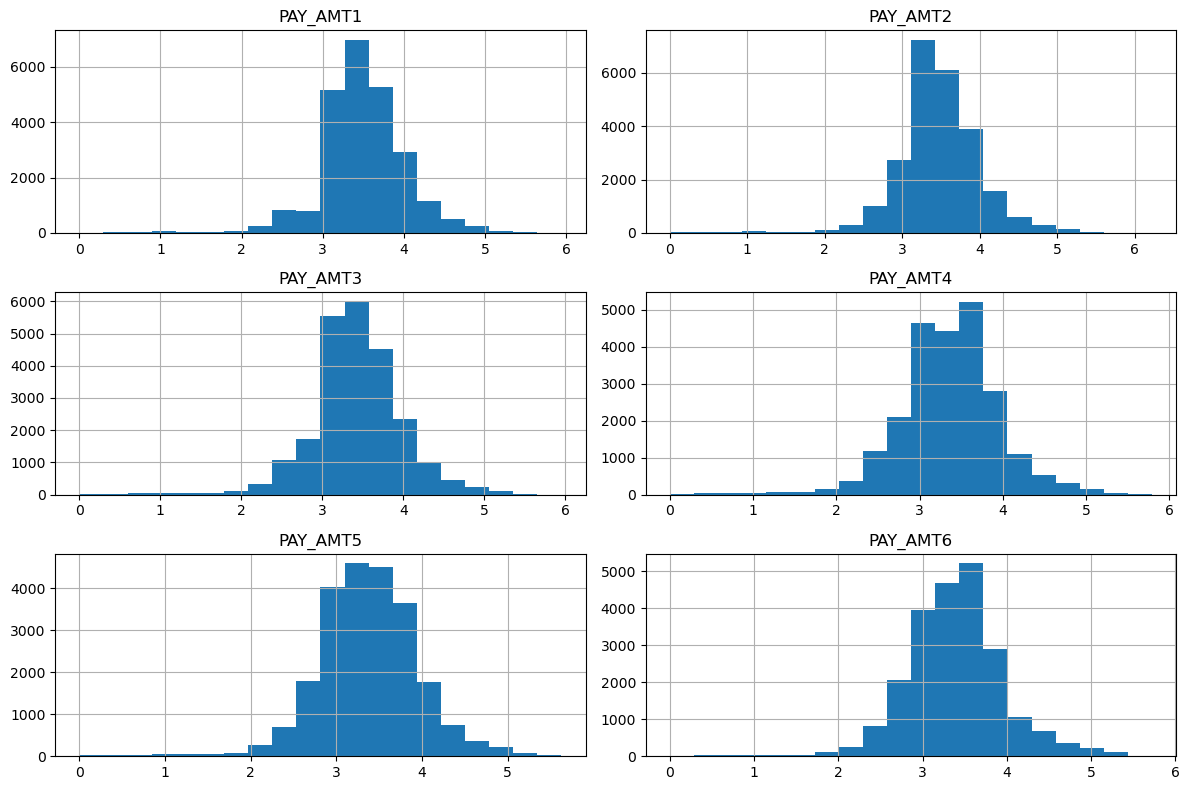

In [24]:
# ignorar zeros
non_zero = df[pay_features].replace(0, np.nan)

# aplicar log10
log_data = non_zero.apply(np.log10)

# plotar
log_data.hist(bins=20, figsize=(12,8))
plt.tight_layout()
plt.show()

Após aplicar a transformação logarítmica, a distribuição dos dados tornou-se mais simétrica, reduzindo o impacto de valores extremos. Isso facilita a análise e interpretação dos dados, tornando os padrões mais visíveis.